In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

In [43]:
Obesity= pd.read_csv("C:\\Users\\effie\\Downloads\\archive (25)\\ObesityDataSet_raw_and_data_sinthetic.csv")

In [39]:
Obesity.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [41]:
Obesity.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [43]:
Obesity.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.586035,2.418986,2.685651,2.008053,1.010313,0.657861
std,6.357078,0.093368,26.191163,0.533996,0.778079,0.612950,0.850613,0.608926
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.630000,65.470000,2.000000,2.660000,1.585000,0.125000,0.000000
50%,23.000000,1.700000,83.000000,2.390000,3.000000,2.000000,1.000000,0.625000
75%,26.000000,1.770000,107.430000,3.000000,3.000000,2.480000,1.670000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [45]:
Obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [47]:
Obesity.shape

(2111, 17)

In [49]:
Obesity.dtypes

Gender                             object
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

In [45]:
# Renaming specific columns
Obesity = Obesity.rename(
    columns={"FAVC": "Frequently_consumes_high_calory_foods", "FCVC": "Frequency_vegconsup","NCP":"No_of_mainsPerDay","CAEC":"Snacking","CH20":"Water_Intake",
            "SCC":"Monitor_CalIntake","FAF":"Physicals", "TUE":"Tech_Usage","CALC":"AlcoholIntake","MTRANS":"Transportation_Mode","NObeyesdad":"Obesity_Level"}
)

print(Obesity)

      Gender  Age  Height  Weight family_history_with_overweight  \
0     Female   21    1.62   64.00                            yes   
1     Female   21    1.52   56.00                            yes   
2       Male   23    1.80   77.00                            yes   
3       Male   27    1.80   87.00                             no   
4       Male   22    1.78   89.80                             no   
...      ...  ...     ...     ...                            ...   
2106  Female   21    1.71  131.41                            yes   
2107  Female   22    1.75  133.74                            yes   
2108  Female   23    1.75  133.69                            yes   
2109  Female   24    1.74  133.35                            yes   
2110  Female   24    1.74  133.47                            yes   

     Frequently_consumes_high_calory_foods  Frequency_vegconsup  \
0                                       no                  2.0   
1                                       no       

In [13]:
Obesity.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'Frequently_consumes_high_calory_foods', 'Frequency_vegconsup',
       'No_of_mainsPerDay', 'Snacking', 'SMOKE', 'CH2O', 'Monitor_CalIntake',
       'Physicals', 'Tech_Usage', 'AlcoholIntake', 'Transportation_Mode',
       'Obesity_Level'],
      dtype='object')

In [69]:
#getting proportions of Obesity
Obesity['Obesity_Level'].value_counts(normalize=True) 
#Dataset is well balanced

Obesity_Level
Obesity_Type_I         0.166272
Obesity_Type_III       0.153482
Obesity_Type_II        0.140692
Overweight_Level_I     0.137376
Overweight_Level_II    0.137376
Normal_Weight          0.135955
Insufficient_Weight    0.128849
Name: proportion, dtype: float64

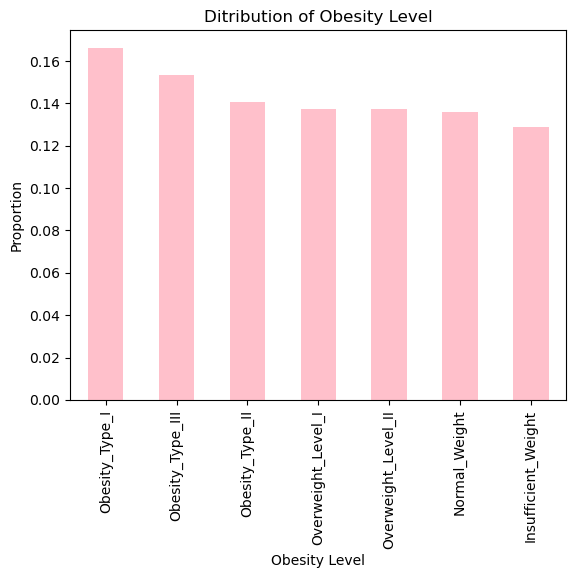

In [67]:
#Visualizing proportions
Obesity['Obesity_Level'].value_counts(normalize=True).plot(
    kind='bar',
    color=['pink']
)
plt.title("Ditribution of Obesity Level")
plt.xlabel("Obesity Level")
plt.ylabel("Proportion")
plt.show()


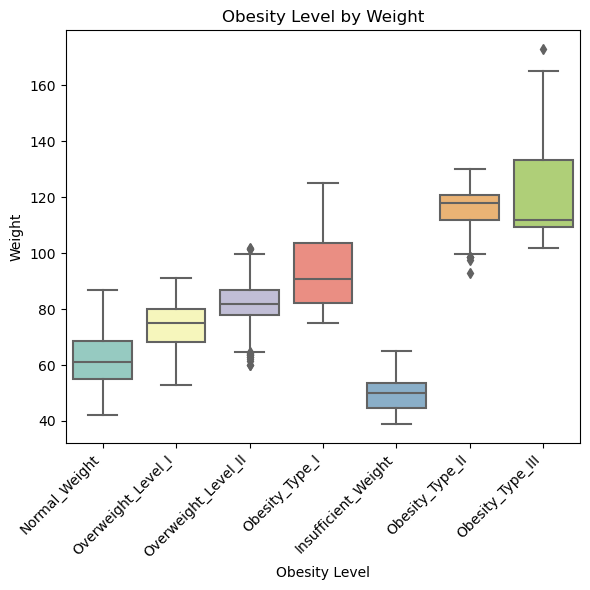

In [17]:
# Obesity Level by Weight
plt.figure(figsize=(6, 6))
sns.boxplot(x='Obesity_Level', y='Weight', data=Obesity, palette='Set3')
plt.title("Obesity Level by Weight")
plt.xlabel("Obesity Level")
plt.ylabel("Weight")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

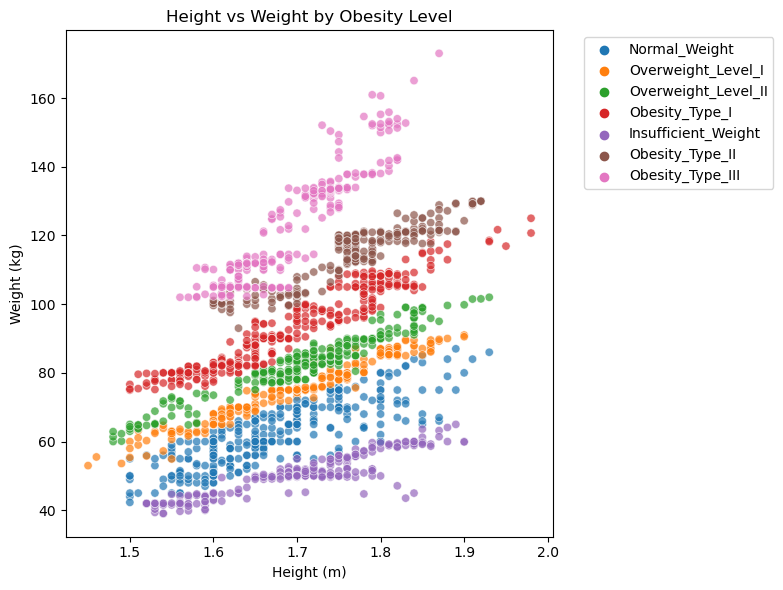

In [21]:
# Height vs Weight scatter, colored by Obesity_Level
plt.figure(figsize=(8, 6))
sns.scatterplot(data=Obesity, x='Height', y='Weight', hue='Obesity_Level',
                 palette='tab10', alpha=0.7)
plt.title('Height vs Weight by Obesity Level')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('2_height_vs_weight.png', dpi=150)
plt.show()
#Height + Weight provides near-perfect predictive power for identifying Obesity_Level

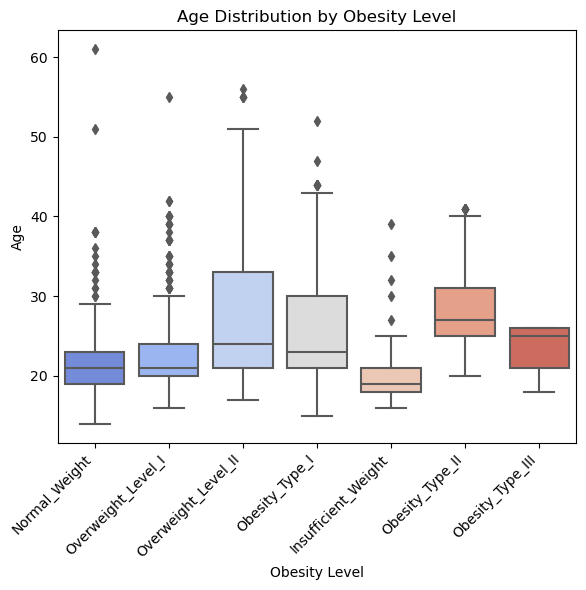

In [33]:
#Age across Obesity_Level
plt.figure(figsize=(6, 6))
sns.boxplot(x='Obesity_Level', y='Age', data= Obesity, palette='coolwarm')
plt.title('Age Distribution by Obesity Level')
plt.xlabel("Obesity Level")
plt.ylabel("Age")
 
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



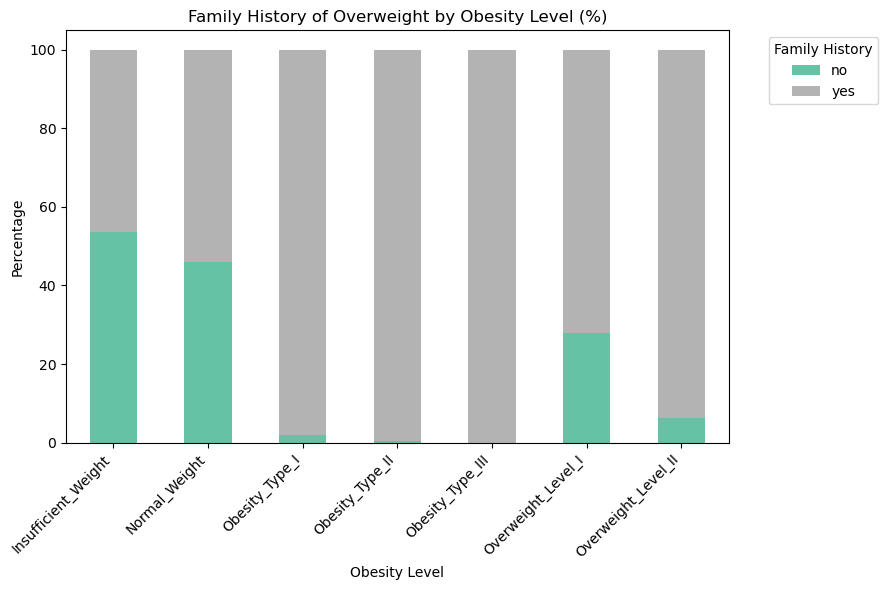

In [39]:
# family_history_with_overweight vs Obesity_Level
cross_tab = pd.crosstab(Obesity['Obesity_Level'], Obesity['family_history_with_overweight'],
                         normalize='index') * 100
 cross_tab.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='Set2')
plt.title('Family History of Overweight by Obesity Level (%)')
plt.xlabel('Obesity Level')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Family History', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()
#Having a family history of overweight is almost universally present among individuals in severe obesity categories.

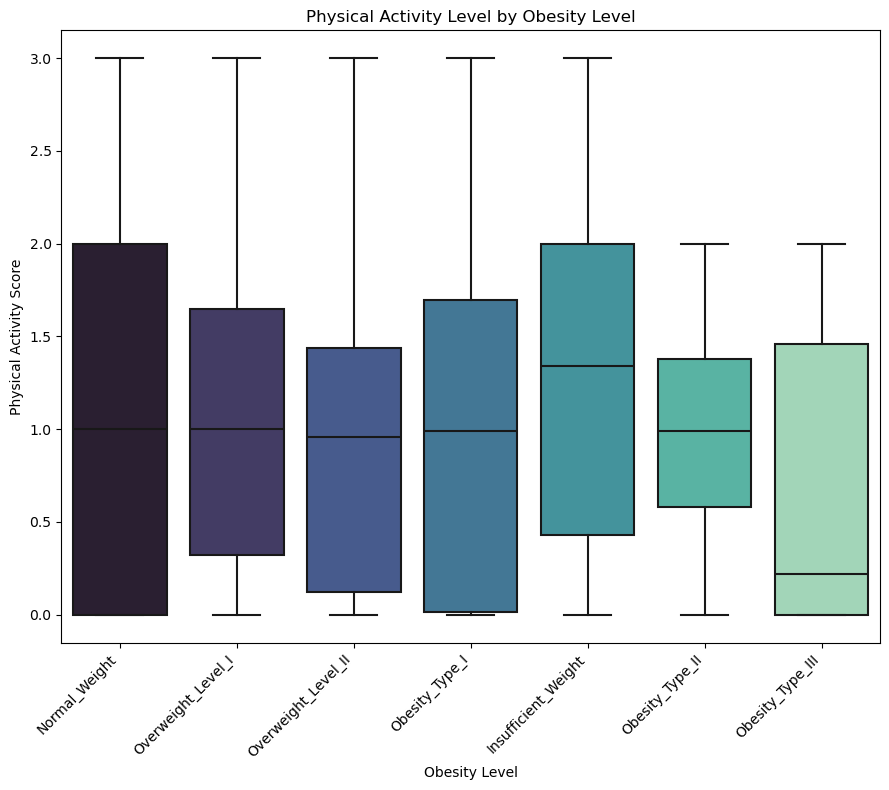

In [61]:
#Physical activity (Physicals) vs Obesity_Level
plt.figure(figsize=(9, 8))
sns.boxplot(data=Obesity, x='Obesity_Level', y='Physicals', palette='mako')
plt.title('Physical Activity Level by Obesity Level')
plt.xlabel('Obesity Level')
plt.ylabel('Physical Activity Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()
#Lowest Physical Activity in Severe Obesity (Obesity_Type_III)
#Physical activity does remains moderate (1.0 median) through the overweight and mild obesity stages, then drops sharply once individuals reach Obesity_Type_III. 
#This suggests physical activity functions more as a strong differentiator for extreme classes rather than a linear predictor

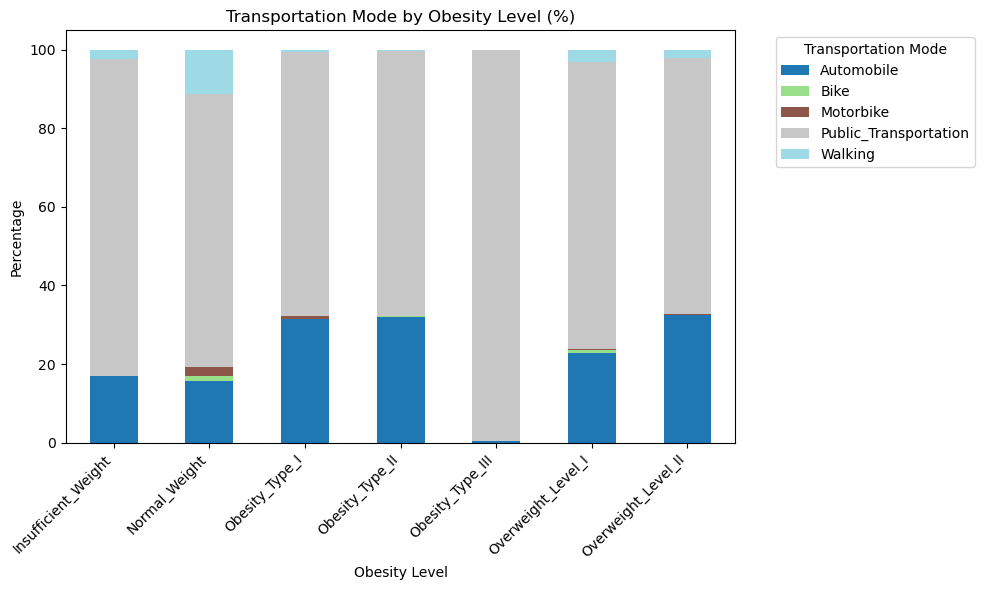

In [65]:
#Transportation_Mode vs Obesity_Level — stacked bar
cross_tab_transport = pd.crosstab(Obesity['Obesity_Level'], Obesity['Transportation_Mode'],
                                   normalize='index') * 100

cross_tab_transport.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Transportation Mode by Obesity Level (%)')
plt.xlabel('Obesity Level')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Transportation Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()
#Public Transportation Dominates Across All Categories
#Automobile Use Increases in Mid-to-High Weight Categories
#Active Transportation is Virtually Negligible


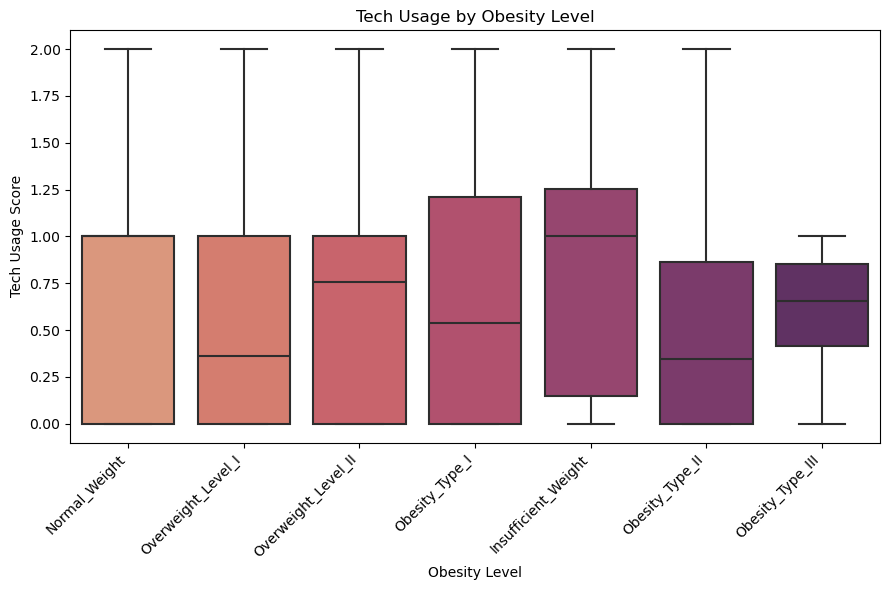

In [69]:
#Tech_Usage vs Obesity_Level — boxplot

plt.figure(figsize=(9, 6))
sns.boxplot(data=Obesity, x='Obesity_Level', y='Tech_Usage', palette='flare')
plt.title('Tech Usage by Obesity Level')
plt.xlabel('Obesity Level')
plt.ylabel('Tech Usage Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()
#individuals in the lower-weight tier report the most intensive daily technology usage

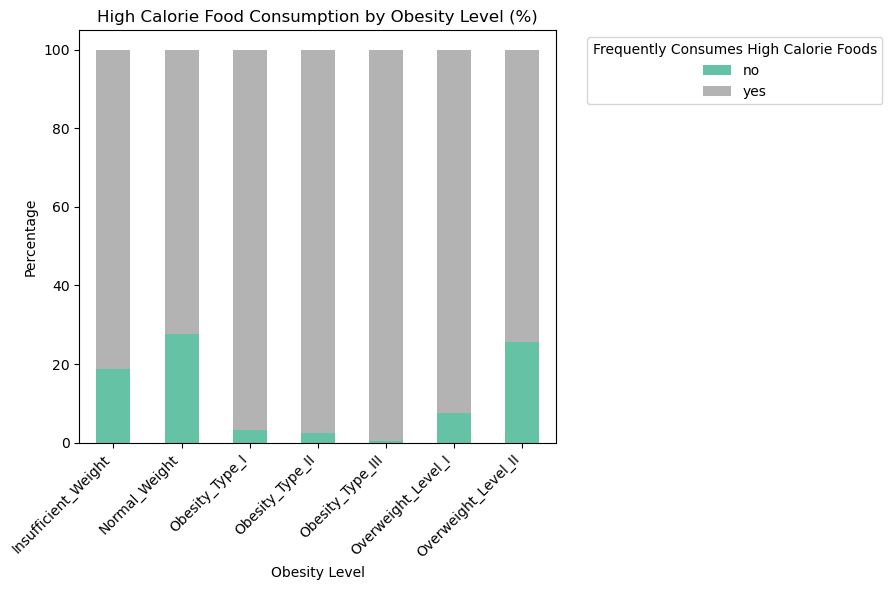

In [23]:
# High calorie consumption vs Obesity_Level
cross_tab_calories = pd.crosstab(Obesity['Obesity_Level'], Obesity['Frequently_consumes_high_calory_foods'],
                                  normalize='index') * 100

cross_tab_calories.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='Set2')
plt.title('High Calorie Food Consumption by Obesity Level (%)')
plt.xlabel('Obesity Level')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Frequently Consumes High Calorie Foods', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [27]:
Obesity.dtypes

Gender                                    object
Age                                        int64
Height                                   float64
Weight                                   float64
family_history_with_overweight            object
Frequently_consumes_high_calory_foods     object
Frequency_vegconsup                      float64
No_of_mainsPerDay                        float64
Snacking                                  object
SMOKE                                     object
CH2O                                     float64
Monitor_CalIntake                         object
Physicals                                float64
Tech_Usage                               float64
AlcoholIntake                             object
Transportation_Mode                       object
Obesity_Level                             object
dtype: object

In [27]:
Obesity.describe()

,Age,Height,Weight,Frequency_vegconsup,No_of_mainsPerDay,CH2O,Physicals,Tech_Usage
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.586035,2.418986,2.685651,2.008053,1.010313,0.657861
std,6.357078,0.093368,26.191163,0.533996,0.778079,0.612950,0.850613,0.608926
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.630000,65.470000,2.000000,2.660000,1.585000,0.125000,0.000000
50%,23.000000,1.700000,83.000000,2.390000,3.000000,2.000000,1.000000,0.625000
75%,26.000000,1.770000,107.430000,3.000000,3.000000,2.480000,1.670000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [47]:
#Feature engineering
Obesity['BMI'] = Obesity['Weight'] / (Obesity['Height'] ** 2)

In [49]:
#Lifestyle
Obesity['Unhealthy_Score'] = (
    (Obesity['Frequently_consumes_high_calory_foods'] == 'yes').astype(int) +
    (Obesity['SMOKE'] == 'yes').astype(int) +
    (Obesity['family_history_with_overweight'] == 'yes').astype(int) +
    (3 - Obesity['Physicals'])  #Because low activity = higher risk
)

In [51]:
#Tech-to-activity balance
Obesity['Sedentary_Ratio'] = Obesity['Tech_Usage'] / (Obesity['Physicals'] + 1) 

In [53]:
#Water-to-meals ratio
Obesity['Hydration_per_Meal'] = Obesity['CH2O'] / Obesity['No_of_mainsPerDay']

In [55]:
#Age Group
Obesity['Age_Group'] = pd.cut(Obesity['Age'], bins=[0, 20, 30, 40, 100],
                                labels=['Teen', 'YoungAdult', 'Adult', 'Older'])


In [57]:
print(Obesity['Obesity_Level'].unique())

['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


In [59]:
# Converting categorical columns to numerical
# Identifying categorical columns automatically (include both object AND category dtypes)
categorical_cols = Obesity.select_dtypes(include=['object', 'category']).columns.tolist()

# Dropping the target column from encoding
categorical_cols.remove('Obesity_Level')

# One-hot encoding all categorical features
Obesity_encoded = pd.get_dummies(Obesity, columns=categorical_cols, drop_first=True)

# Checking the new shape
print(Obesity_encoded.shape)

(2111, 31)


In [61]:
#Scaling Numerical Variables
numeric_cols = ['Age', 'Height', 'Weight', 'Frequency_vegconsup', 'No_of_mainsPerDay',
                 'CH2O', 'Tech_Usage', 'Physicals',
                 'BMI', 'Unhealthy_Score', 'Hydration_per_Meal', 'Sedentary_Ratio']

scaler = StandardScaler()
Obesity_encoded[numeric_cols] = scaler.fit_transform(Obesity_encoded[numeric_cols])

In [63]:
#Encoding target variable
le = LabelEncoder()
Obesity_encoded['Obesity_Level'] = le.fit_transform(Obesity['Obesity_Level'])

# Checking the mapping
dict(zip(le.classes_, le.transform(le.classes_)))

{'Insufficient_Weight': 0,
 'Normal_Weight': 1,
 'Obesity_Type_I': 2,
 'Obesity_Type_II': 3,
 'Obesity_Type_III': 4,
 'Overweight_Level_I': 5,
 'Overweight_Level_II': 6}

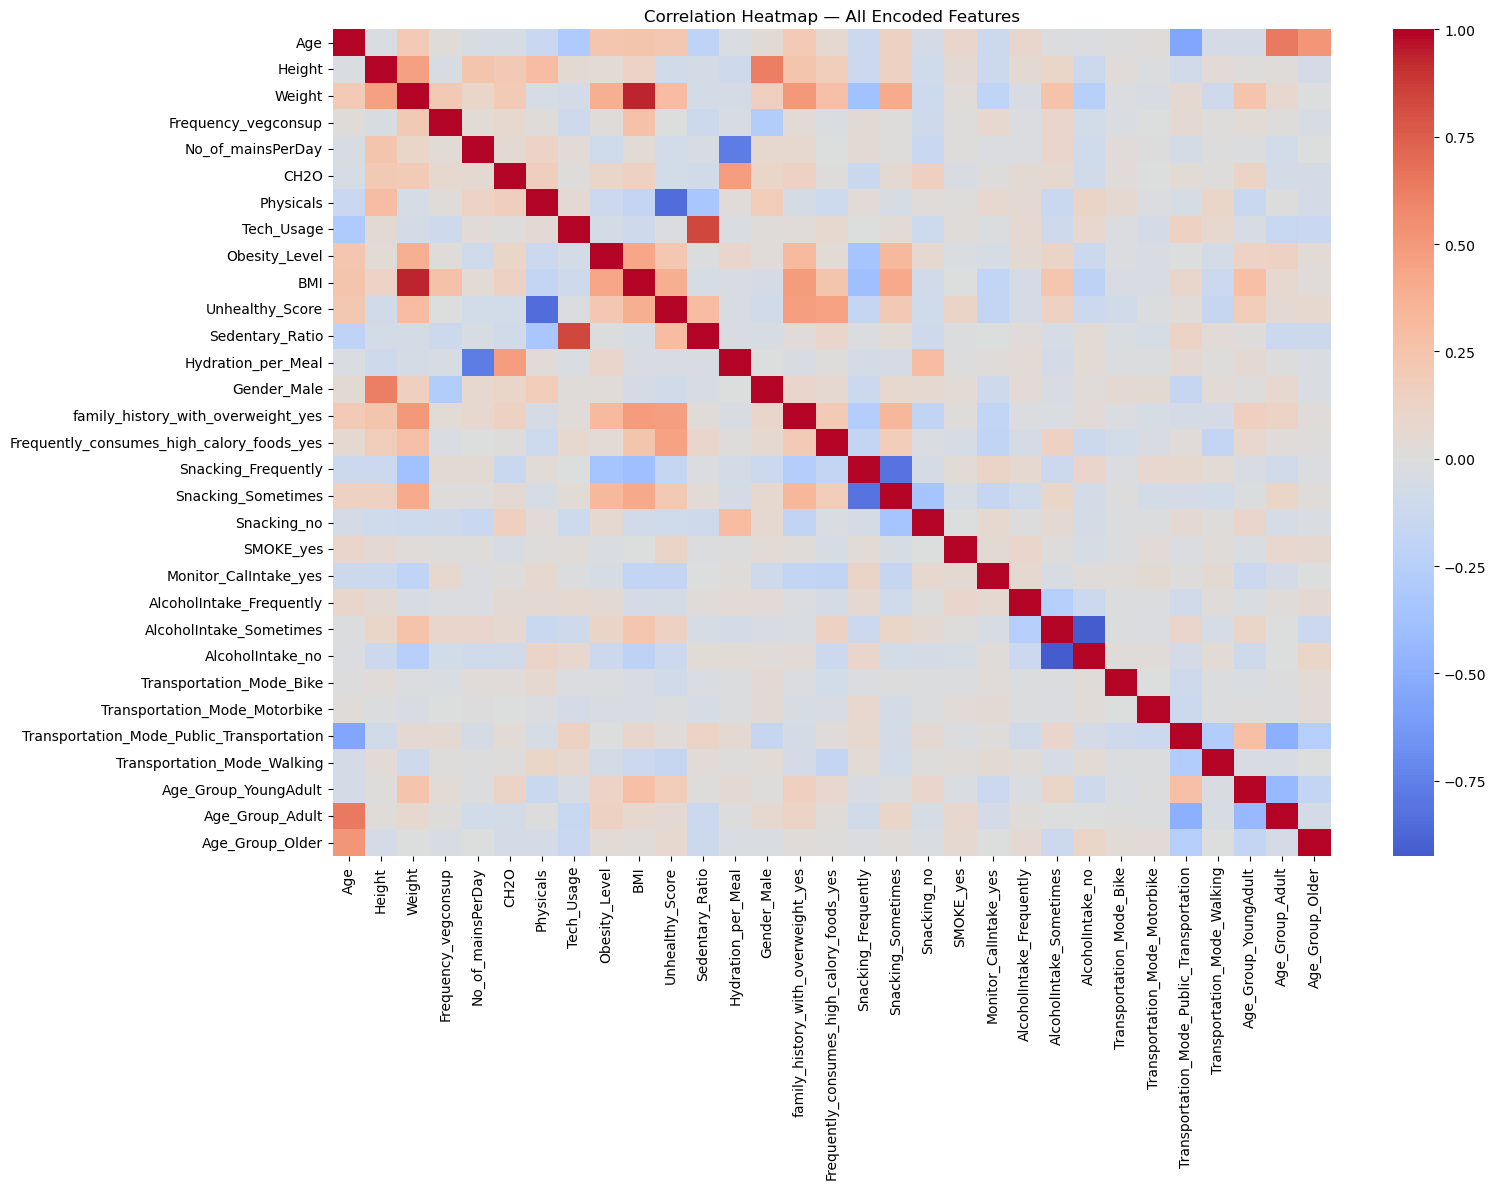

In [25]:
plt.figure(figsize=(16, 12))
corr = Obesity_encoded.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — All Encoded Features')
plt.tight_layout()
plt.show()



In [65]:
target_corr = Obesity_encoded.corr()['Obesity_Level'].sort_values(ascending=False)
print(target_corr)

Obesity_Level                                1.000000
BMI                                          0.429204
Weight                                       0.387641
Snacking_Sometimes                           0.316962
family_history_with_overweight_yes           0.313667
Age                                          0.235660
Unhealthy_Score                              0.227119
Age_Group_Adult                              0.143341
Age_Group_YoungAdult                         0.130172
AlcoholIntake_Sometimes                      0.114104
CH2O                                         0.108839
Hydration_per_Meal                           0.090812
Snacking_no                                  0.066715
AlcoholIntake_Frequently                     0.047318
Frequently_consumes_high_calory_foods_yes    0.044582
Age_Group_Older                              0.042573
Height                                       0.039671
Gender_Male                                  0.024908
Frequency_vegconsup         

In [25]:
Obesity_encoded[['BMI', 'Weight', 'Height']].corr()

,BMI,Weight,Height
BMI,1.000000,0.934556,0.130162
Weight,0.934556,1.000000,0.462264
Height,0.130162,0.462264,1.000000


In [39]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 187.9 kB/s eta 0:09:02
   ---------------------------------------- 0.0/101.7 MB 187.9 kB/s eta 0:09:02
   ---------------------------------------- 0.0/101.7 MB 187.9 kB/s eta 0:09:02
   ---------------------------------------- 0.1/101.7 MB 204.8 kB/s eta 0:08:17
   ---------------------------------------- 0.1/101.7 MB 206.9 kB/s eta 0:08:12
   ---------------------------------------- 0.1/101.7 MB 249.8 kB/s eta 0:06:47
   ---------------------------------------- 0.1/101.7 MB 249.8 kB/s eta 0:06:47
   ---------------------------------------- 0.1/101.7 MB 218.4 kB/s eta 0:07:46
   ---------------------------------------- 0.2/101.7 MB 286.7 kB/s eta 0:05:55
   ---------------------------------------- 0.2/101.7 MB 355.7 kB/s

In [67]:
#Train/test split (80/20, stratified)
X = Obesity_encoded.drop('Obesity_Level', axis=1)
y = Obesity_encoded['Obesity_Level']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
 

Train shape: (1688, 30), Test shape: (423, 30)


In [69]:

# Defining models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}
 

In [71]:
Obesity_encoded['Obesity_Level'], class_names = pd.factorize(Obesity_encoded['Obesity_Level'])


Logistic Regression
Test Accuracy: 0.9125
CV Accuracy: 0.9052 (+/- 0.0116)

Classification Report:
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        54
           5       0.86      0.76      0.81        58
           6       0.94      0.96      0.95        70
           2       0.98      1.00      0.99        60
           0       1.00      0.98      0.99        65
           3       0.77      0.79      0.78        58
           4       0.86      0.88      0.87        58

    accuracy                           0.91       423
   macro avg       0.91      0.91      0.91       423
weighted avg       0.91      0.91      0.91       423



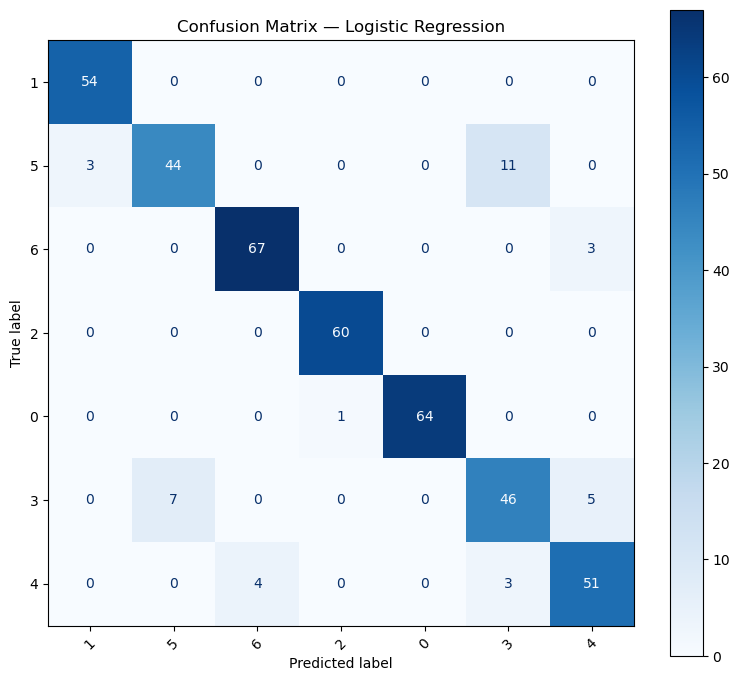


Decision Tree
Test Accuracy: 0.9811
CV Accuracy: 0.9668 (+/- 0.0043)

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        54
           5       1.00      1.00      1.00        58
           6       0.96      0.99      0.97        70
           2       0.97      0.95      0.96        60
           0       1.00      0.98      0.99        65
           3       0.97      0.98      0.97        58
           4       0.98      0.97      0.97        58

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423



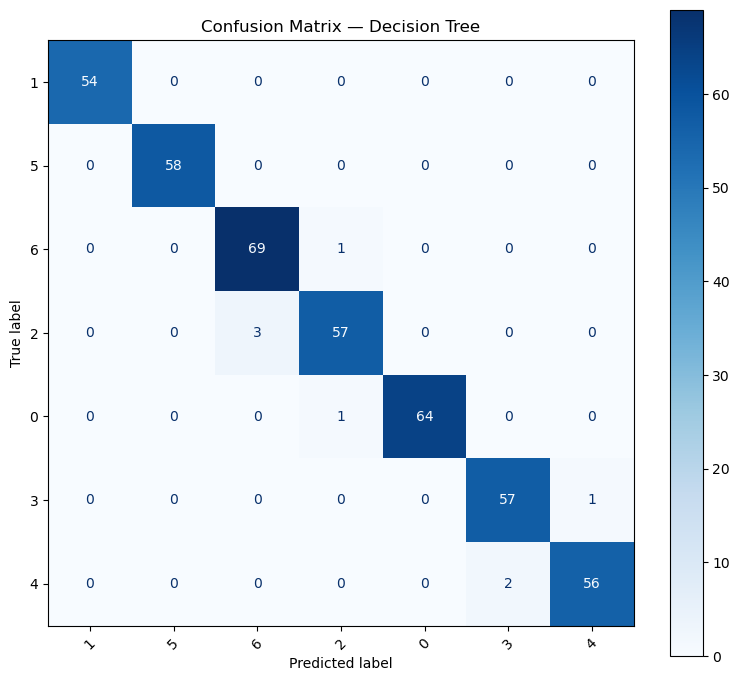


Random Forest
Test Accuracy: 0.9764
CV Accuracy: 0.9864 (+/- 0.0072)

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.98      0.99        54
           5       0.88      0.98      0.93        58
           6       0.99      1.00      0.99        70
           2       1.00      0.98      0.99        60
           0       1.00      1.00      1.00        65
           3       0.98      0.90      0.94        58
           4       1.00      0.98      0.99        58

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423



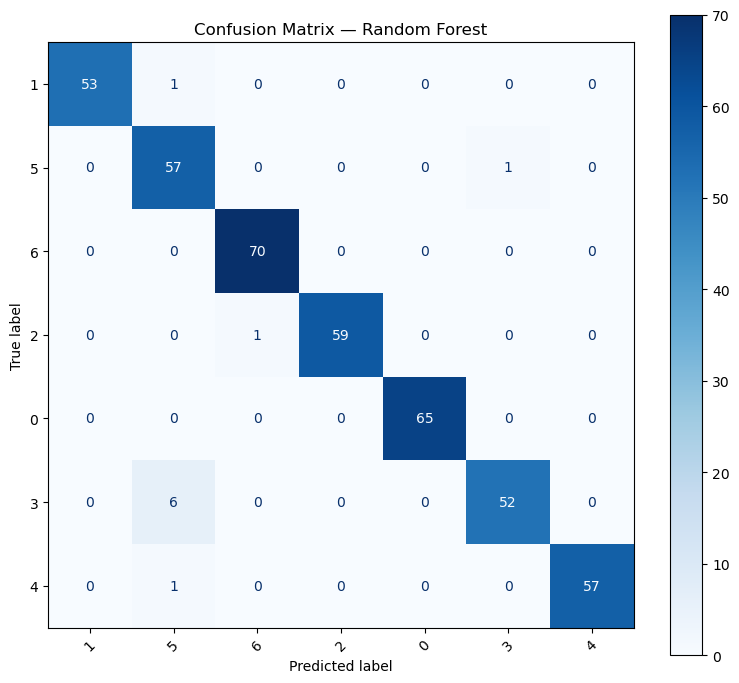


XGBoost
Test Accuracy: 0.9835
CV Accuracy: 0.9769 (+/- 0.0093)

Classification Report:
              precision    recall  f1-score   support

           1       0.98      1.00      0.99        54
           5       0.98      0.97      0.97        58
           6       0.99      1.00      0.99        70
           2       0.98      1.00      0.99        60
           0       1.00      0.98      0.99        65
           3       0.97      0.97      0.97        58
           4       0.98      0.97      0.97        58

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423



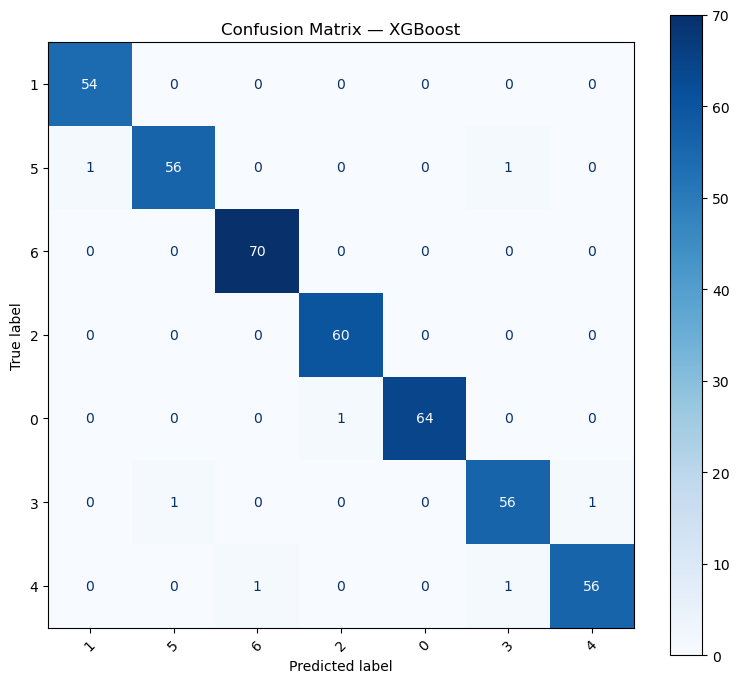


SVM
Test Accuracy: 0.9456
CV Accuracy: 0.9360 (+/- 0.0121)

Classification Report:
              precision    recall  f1-score   support

           1       0.98      1.00      0.99        54
           5       0.87      0.90      0.88        58
           6       0.96      0.97      0.96        70
           2       1.00      0.98      0.99        60
           0       1.00      1.00      1.00        65
           3       0.88      0.86      0.87        58
           4       0.93      0.90      0.91        58

    accuracy                           0.95       423
   macro avg       0.94      0.94      0.94       423
weighted avg       0.95      0.95      0.95       423



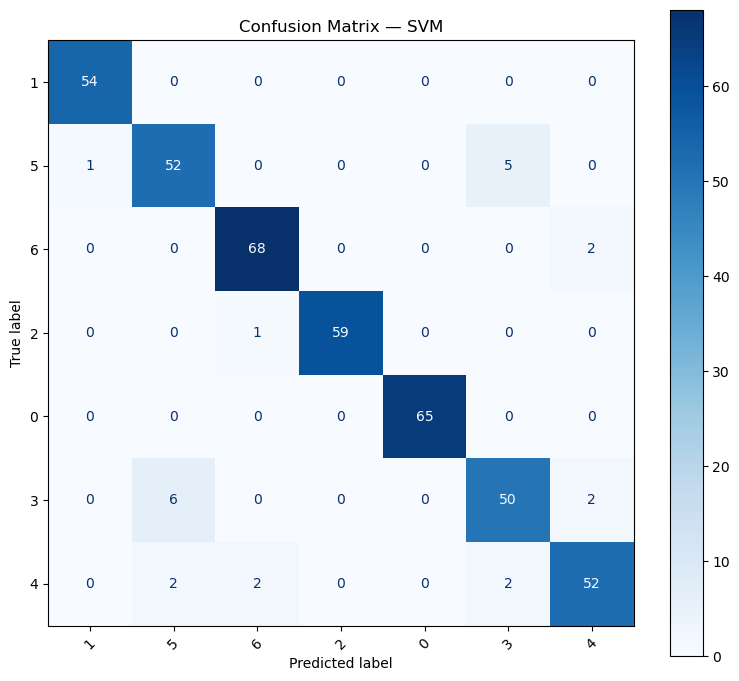

In [73]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Training, predicting, evaluating, and cross-validating each model
results = {}

for name, model in models.items():
    print(f"\n{'='*60}\n{name}\n{'='*60}")

    # Fit on train, evaluate on test (as before)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    # Cross-validation on the training set (checks stability, avoids touching test set)
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')

    results[name] = {
        'Test Accuracy': acc,
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std Dev': cv_scores.std()
    }

    print(f"Test Accuracy: {acc:.4f}")
    print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()

In [43]:
Obesity_encoded['Obesity_Level'], class_names = pd.factorize(Obesity['Obesity_Level'])
print(list(enumerate(class_names)))

[(0, 'Normal_Weight'), (1, 'Overweight_Level_I'), (2, 'Overweight_Level_II'), (3, 'Obesity_Type_I'), (4, 'Insufficient_Weight'), (5, 'Obesity_Type_II'), (6, 'Obesity_Type_III')]


Stacking Classifier Test Accuracy: 0.9882

Stacking CV Accuracy: 0.9822 (+/- 0.0090)

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        54
           5       0.98      0.98      0.98        58
           6       1.00      1.00      1.00        70
           2       0.98      1.00      0.99        60
           0       1.00      0.98      0.99        65
           3       0.97      0.97      0.97        58
           4       0.98      0.98      0.98        58

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423



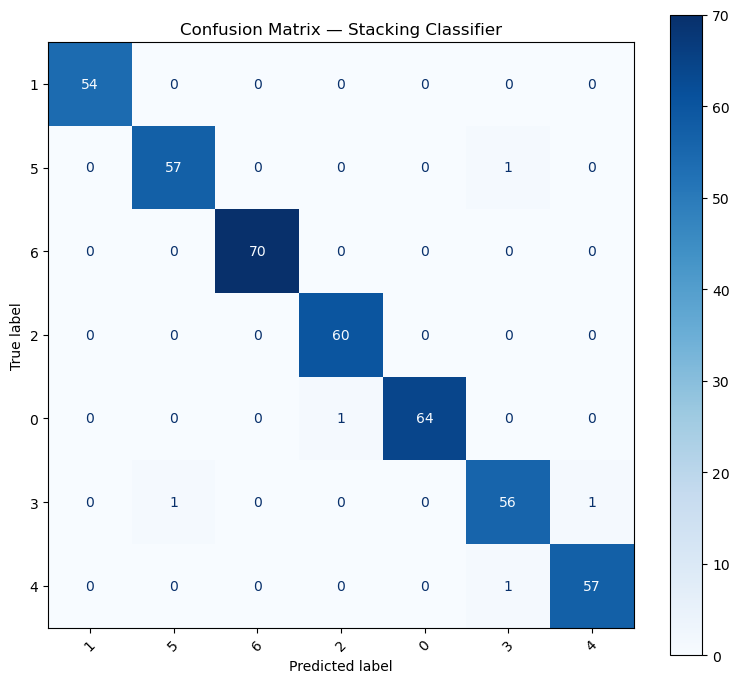

In [81]:

from sklearn.model_selection import cross_val_score, StratifiedKFold

estimators = [
    ('xgb', XGBClassifier(eval_metric='mlogloss', random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42))
]

# Meta-learner that combines their predictions
stacked_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

# Fit and predict
stacked_model.fit(X_train, y_train)
y_pred_stack = stacked_model.predict(X_test)

# Evaluating on test set
acc_stack = accuracy_score(y_test, y_pred_stack)
print(f"Stacking Classifier Test Accuracy: {acc_stack:.4f}\n")

# Cross-validation on training set (stability check)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_stack = cross_val_score(stacked_model, X_train, y_train, cv=skf, scoring='accuracy')
print(f"Stacking CV Accuracy: {cv_scores_stack.mean():.4f} (+/- {cv_scores_stack.std():.4f})\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_stack, target_names=[str(c) for c in class_names]))

# Confusion matrix
cm_stack = confusion_matrix(y_test, y_pred_stack)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_stack, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix — Stacking Classifier')
plt.tight_layout()
plt.show()

In [108]:
# Getting feature importance from Random Forest (your top standalone model)
importances = pd.Series(models['Random Forest'].feature_importances_, index=X_train.columns)
top_15 = importances.sort_values(ascending=False).head(15)
print(top_15)

BMI                                   0.325861
Weight                                0.185398
Frequency_vegconsup                   0.061379
Age                                   0.048930
Height                                0.047308
Gender_Male                           0.045995
No_of_mainsPerDay                     0.027978
Unhealthy_Score                       0.027448
Hydration_per_Meal                    0.025805
Tech_Usage                            0.022162
Sedentary_Ratio                       0.021968
CH2O                                  0.021633
Physicals                             0.020809
family_history_with_overweight_yes    0.019781
Snacking_Sometimes                    0.015843
dtype: float64


In [110]:
# Ablation check
X_train_no_gender = X_train.drop('Gender_Male', axis=1)
X_test_no_gender = X_test.drop('Gender_Male', axis=1)

rf_no_gender = RandomForestClassifier(n_estimators=200, random_state=42)
rf_no_gender.fit(X_train_no_gender, y_train)
y_pred_no_gender = rf_no_gender.predict(X_test_no_gender)
print(f"Random Forest Accuracy without Gender: {accuracy_score(y_test, y_pred_no_gender):.4f}")

Random Forest Accuracy without Gender: 0.9835


In [112]:
# Dropping Gender_Male — confirmed non-predictive via ablation test
X_train_final = X_train.drop('Gender_Male', axis=1)
X_test_final = X_test.drop('Gender_Male', axis=1)

# Retrain Random Forest on the cleaned feature set
model_final = RandomForestClassifier(n_estimators=200, random_state=42)
model_final.fit(X_train_final, y_train)

y_pred_final = model_final.predict(X_test_final)
acc_final = accuracy_score(y_test, y_pred_final)
print(f"Random Forest Accuracy (Gender_Male removed): {acc_final:.4f}")

# Final feature importance ranking
importances = pd.Series(model_final.feature_importances_, index=X_train_final.columns)
top_15 = importances.sort_values(ascending=False).head(15)
print(top_15)

Random Forest Accuracy (Gender_Male removed): 0.9835
BMI                                   0.354472
Weight                                0.178756
Frequency_vegconsup                   0.066184
Height                                0.053639
Age                                   0.052930
Unhealthy_Score                       0.029720
Hydration_per_Meal                    0.027607
No_of_mainsPerDay                     0.026659
Tech_Usage                            0.024421
CH2O                                  0.023638
Physicals                             0.023509
Sedentary_Ratio                       0.023056
family_history_with_overweight_yes    0.018280
AlcoholIntake_no                      0.013972
Snacking_Sometimes                    0.013551
dtype: float64
